In [32]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import joblib

In [33]:
with open('data/Spending_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)

In [34]:
df

,Income (VND),Gender,Personality,Marital Status,Expenditure (VND)
0,33200604,Female,Introvert,Single,25893046.0
1,26094478,Male,Introvert,Single,13629905.0
2,33327850,Female,Introvert,Single,25199747.0
3,36858567,Male,Introvert,Married,21103260.0
4,31081788,Female,Introvert,Married,23858401.0
...,...,...,...,...,...
4995,39698493,Female,Introvert,Single,26928171.0
4996,11578315,Female,Extrovert,Married,9607838.0
4997,17427210,Female,Extrovert,Single,15015119.0
4998,35076068,Female,Extrovert,Single,16769067.0


In [35]:
df['Personality'].value_counts()

Personality
Introvert    2918
Extrovert    2082
Name: count, dtype: int64

In [36]:
df_encoded = df.copy()
df_encoded['Is_Male'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)
df_encoded['Is_Introvert'] = df['Personality'].apply(lambda x: 1 if x == 'Introvert' else 0)
df_encoded['Is_Married'] = df['Marital Status'].apply(lambda x: 1 if x == 'Married' else 0)

In [37]:
df_encoded


,Income (VND),Gender,Personality,Marital Status,Expenditure (VND),Is_Male,Is_Introvert,Is_Married
0,33200604,Female,Introvert,Single,25893046.0,0,1,0
1,26094478,Male,Introvert,Single,13629905.0,1,1,0
2,33327850,Female,Introvert,Single,25199747.0,0,1,0
3,36858567,Male,Introvert,Married,21103260.0,1,1,1
4,31081788,Female,Introvert,Married,23858401.0,0,1,1
...,...,...,...,...,...,...,...,...
4995,39698493,Female,Introvert,Single,26928171.0,0,1,0
4996,11578315,Female,Extrovert,Married,9607838.0,0,0,1
4997,17427210,Female,Extrovert,Single,15015119.0,0,0,0
4998,35076068,Female,Extrovert,Single,16769067.0,0,0,0


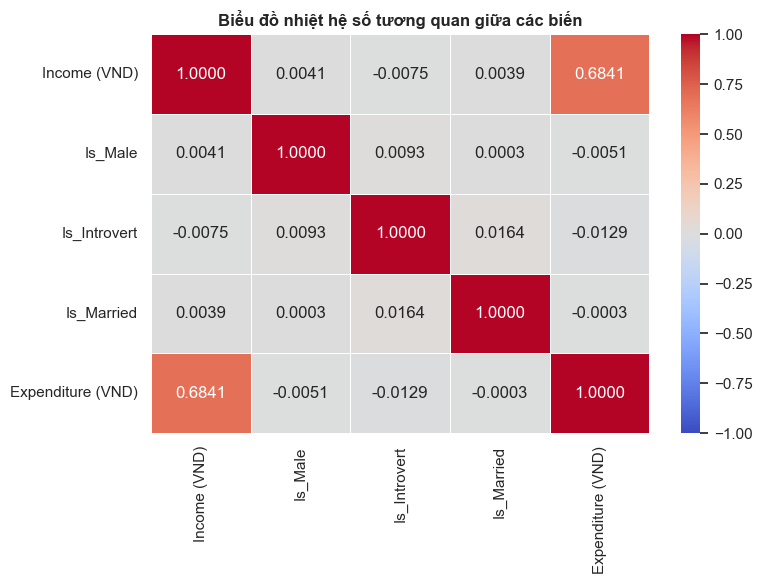

In [38]:
corr_matrix = df_encoded[['Income (VND)', 'Is_Male', 'Is_Introvert', 'Is_Married', 'Expenditure (VND)']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Biểu đồ nhiệt hệ số tương quan giữa các biến', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

- Dựa vào biểu đồ heatmap ta nhận xét gần: Income có tương quan với expenditure trên mức trung bình, nghĩa là có một chút xu hương tăng khi income tăng, các biến còn lại is_male, is_introvert, is_married không có ảnh hưởng rõ rệt, nhưng hiện tại đang âm có nghĩa xu hướng hiện tại có đang nghiên về phía các one-hot là 0. ==> Phân tích như vậy là chưa chính xác.


## Cần phải tách ra 2 nhóm biến : Liên tục và phân loại 

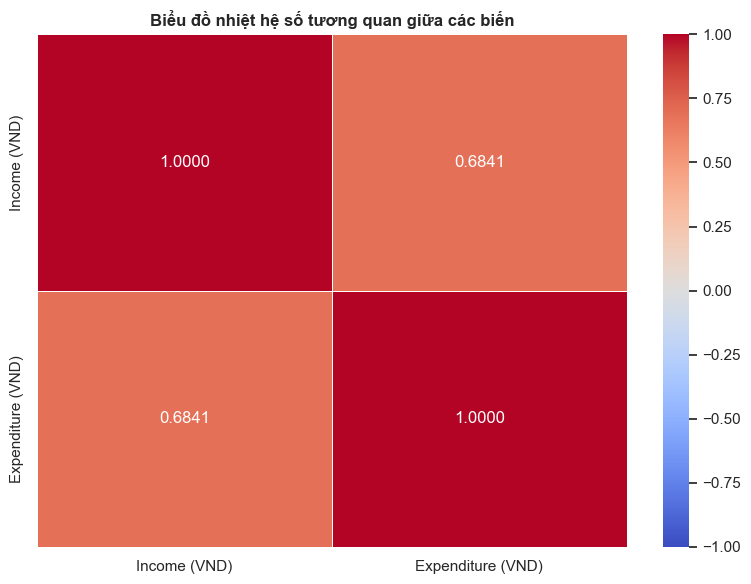

In [39]:
# Phân tích tương quan của nhóm biến liên tục
corr_matrix = df_encoded[['Income (VND)', 'Expenditure (VND)']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Biểu đồ nhiệt hệ số tương quan giữa các biến', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [40]:
df_encoded

,Income (VND),Gender,Personality,Marital Status,Expenditure (VND),Is_Male,Is_Introvert,Is_Married
0,33200604,Female,Introvert,Single,25893046.0,0,1,0
1,26094478,Male,Introvert,Single,13629905.0,1,1,0
2,33327850,Female,Introvert,Single,25199747.0,0,1,0
3,36858567,Male,Introvert,Married,21103260.0,1,1,1
4,31081788,Female,Introvert,Married,23858401.0,0,1,1
...,...,...,...,...,...,...,...,...
4995,39698493,Female,Introvert,Single,26928171.0,0,1,0
4996,11578315,Female,Extrovert,Married,9607838.0,0,0,1
4997,17427210,Female,Extrovert,Single,15015119.0,0,0,0
4998,35076068,Female,Extrovert,Single,16769067.0,0,0,0


In [41]:
from scipy.stats import chi2_contingency
from scipy import stats
def check_chi_square(df, col1, col2):
    """
    Hàm kiểm tra tính độc lập giữa 2 biến phân loại bằng Chi-Square.
    Nhằm phát hiện đa cộng tuyến phân loại.
    """
    # 1. Lập bảng tần suất chéo (Contingency Table) giữa 2 biến
    contingency_table = pd.crosstab(df[col1], df[col2])
    
    # 2. Chạy kiểm định Chi-Square
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table) # 
    
    # 3. In kết quả trực quan
    print(f"--- KIỂM ĐỊNH CHI-SQUARE: [{col1}] & [{col2}] ---")
    print(f"Giá trị thống kê χ² : {chi2_stat:.4f}")
    print(f"p-value             : {p_value:.4f}") # In ra p-value của kiểm định

check_chi_square(df_encoded, 'Gender', 'Personality')
check_chi_square(df_encoded, 'Gender', 'Marital Status')
check_chi_square(df_encoded, 'Personality', 'Marital Status')


--- KIỂM ĐỊNH CHI-SQUARE: [Gender] & [Personality] ---
Giá trị thống kê χ² : 0.3917
p-value             : 0.5314
--- KIỂM ĐỊNH CHI-SQUARE: [Gender] & [Marital Status] ---
Giá trị thống kê χ² : 0.0000
p-value             : 1.0000
--- KIỂM ĐỊNH CHI-SQUARE: [Personality] & [Marital Status] ---
Giá trị thống kê χ² : 1.2786
p-value             : 0.2582


## Ho : Hai biến không liên quan nhau.
- không đủ để bác bỏ Ho => Các biến hoàn toàn độc lập

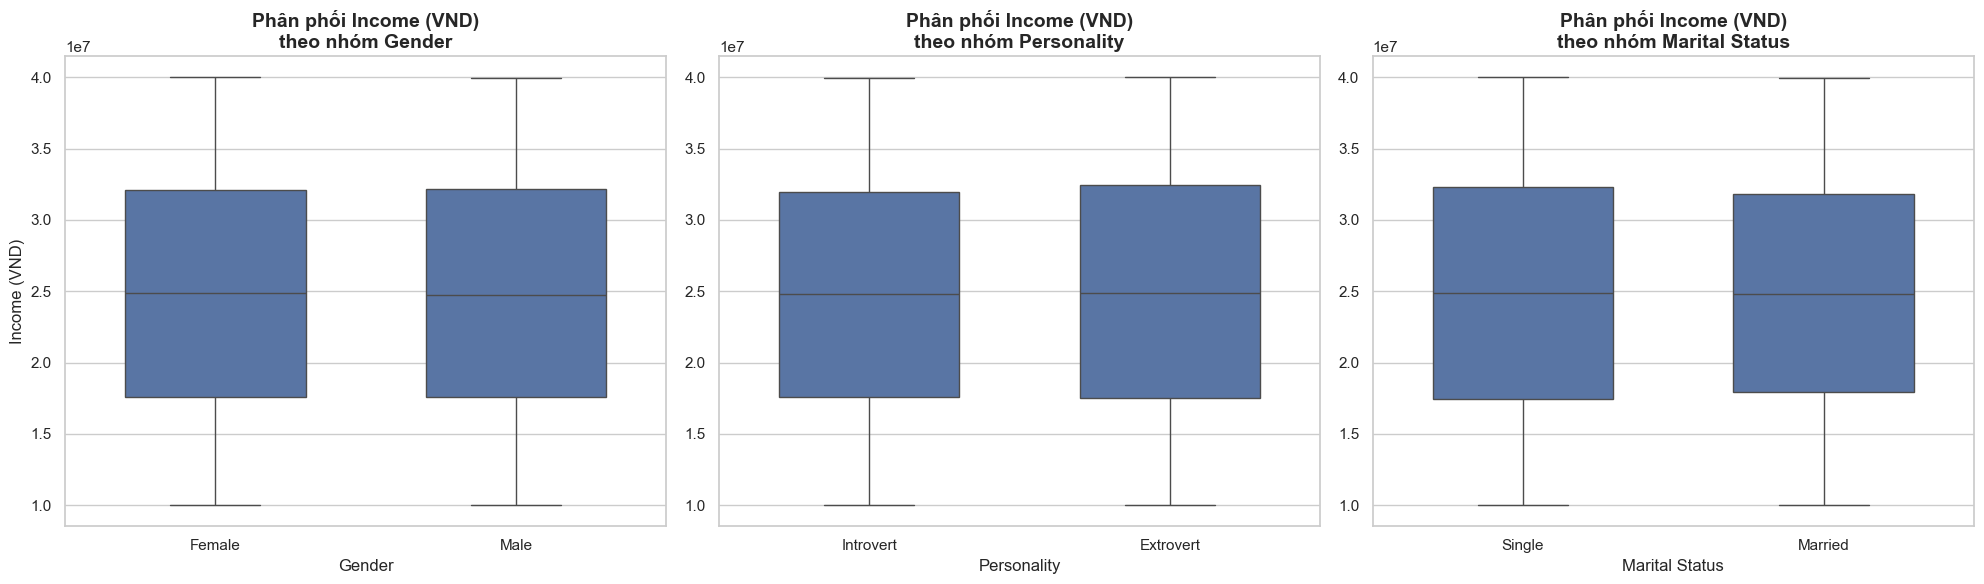

In [42]:
TARGET_COLUMN = 'Income (VND)' 

# Danh sách các biến phân loại cần vẽ (đã xác định là độc lập ở Bước 2)
cat_cols = ['Gender', 'Personality', 'Marital Status']

# Định dạng thẩm mỹ cho biểu đồ
sns.set_theme(style="whitegrid") # Nền trắng có lưới
plt.figure(figsize=(20, 6))      # Thiết lập kích thước khung tranh tổng thể (Rộng, Cao)

# Lặp qua từng biến phân loại để vẽ biểu đồ con (subplot)
for i, col in enumerate(cat_cols, 1):
    # Tạo subplot: 1 hàng, 3 cột, vị trí thứ i
    ax = plt.subplot(1, 3, i)
    
    # Vẽ Boxplot
    # x: Biến phân loại (nhóm)
    # y: Biến mục tiêu (số)
    sns.boxplot(x=col, y=TARGET_COLUMN, data=df, width=0.6)
    
    
    # Trang trí cho từng biểu đồ con
    ax.set_title(f'Phân phối {TARGET_COLUMN}\ntheo nhóm {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel(TARGET_COLUMN if i == 1 else "", fontsize=12) # Chỉ hiện nhãn trục Y ở biểu đồ đầu tiên

# Tự động căn chỉnh khoảng cách giữa các biểu đồ để không bị đè chữ
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

## Xem phân phối thì thấy các biến tương đối giống nhau => Cần phân tích thêm để tránh nhận định nhầm

In [43]:
def filter_by_anova_eta(df, cat_col, target_col):
    """
    Hàm đánh giá sức mạnh của biến phân loại lên biến mục tiêu (số liên tục).
    Sử dụng kiểm định ANOVA và chỉ số Eta-squared (η²).
    """
    # Lọc bỏ các dòng có giá trị NaN ở 2 cột đang xét để hàm không bị lỗi
    valid_data = df[[cat_col, target_col]].dropna()
    
    # 1. CHUẨN BỊ DỮ LIỆU CHO ANOVA
    # Tách biến mục tiêu thành các mảng (arrays) riêng biệt theo từng nhóm phân loại
    groups = [group[target_col].values for name, group in valid_data.groupby(cat_col)]
    
    # 2. CHẠY KIỂM ĐỊNH ANOVA
    f_stat, p_value = stats.f_oneway(*groups)
    
    # 3. TÍNH TOÁN ETA-SQUARED (η²)
    # Tính trung bình của toàn bộ biến mục tiêu
    mean_total = valid_data[target_col].mean()
    
    # Tính Sum of Squares Total (SST)
    ss_total = ((valid_data[target_col] - mean_total) ** 2).sum()
    
    # Tính Sum of Squares Between (SSB)
    ss_between = 0
    for name, group in valid_data.groupby(cat_col):
        ss_between += len(group) * ((group[target_col].mean() - mean_total) ** 2)
        
    # Công thức Eta-squared
    eta_squared = ss_between / ss_total
    
    # 4. TRÌNH BÀY KẾT QUẢ
    print(f"--- ĐÁNH GIÁ BIẾN: [{cat_col}] tác động lên [{target_col}] ---")
    
    # In p-value (dùng định dạng số mũ e nếu quá nhỏ để tránh hiển thị 0.0000)

    print(f"p-value (ANOVA)  : {p_value:.4f} ")
    
    # In Eta-squared
    print(f"Eta-squared (η²) : {eta_squared:.4f}")


for col in cat_cols:
    filter_by_anova_eta(df, col, TARGET_COLUMN)


--- ĐÁNH GIÁ BIẾN: [Gender] tác động lên [Income (VND)] ---
p-value (ANOVA)  : 0.7696 
Eta-squared (η²) : 0.0000
--- ĐÁNH GIÁ BIẾN: [Personality] tác động lên [Income (VND)] ---
p-value (ANOVA)  : 0.5960 
Eta-squared (η²) : 0.0001
--- ĐÁNH GIÁ BIẾN: [Marital Status] tác động lên [Income (VND)] ---
p-value (ANOVA)  : 0.7803 
Eta-squared (η²) : 0.0000


## Ho : Biến độc lập có tác không tác động đến Income 
- thấy p-value > 0.05 => Chấp nhận Ho => Các biến không có tác động đến Income
## Eta-squared đo lường tỷ lệ phần trăm sự biến thiên của Thu nhập được giải thích bởi biến phân loại.
- Các chỉ số không đạt mức 1% => Các biến không có khả năng giải thích Income

In [48]:
X = df_encoded[['Income (VND)']] # Chỉ còn 1 biến thỏa điều kiện (Các biến còn lại chỉ gây nhiễu)
X = sm.add_constant(X) # Thêm hằng số hệ số chặn C
y = df_encoded['Expenditure (VND)']

# Khớp mô hình hồi quy tuyến tính bình phương tối thiểu (OLS)
model = sm.OLS(y, X).fit()

print("="*80)
print("TÓM TẮT KẾT QUẢ MÔ HÌNH HỒI QUY:")
print(model.summary())
print("="*80)

TÓM TẮT KẾT QUẢ MÔ HÌNH HỒI QUY:
                            OLS Regression Results                            
Dep. Variable:      Expenditure (VND)   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     4396.
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        16:59:56   Log-Likelihood:                -83343.
No. Observations:                5000   AIC:                         1.667e+05
Df Residuals:                    4998   BIC:                         1.667e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         4

$$\text{Expenditure} = 4,546,000 + 0.4614 \times \text{Income} - 90,890 \times \text{Is\_Male} - 89,070 \times \text{Is\_Introvert} - 33,590 \times \text{Is\_Married}$$
(Khi các yếu tố khác không đổi)
- Chi tiêu cơ bản tối thiểu khi thu nhập và các biến định tính bằng 0 là 4,546,000
- Thu nhập tăng $1$ VND thì chi tiêu tăng trung bình $0.4614$ VND
- Đều có giá trị âm (làm giảm chi tiêu từ $33k$ đến $90k$ VND

$H_0$ (Mô hình không phù hợp) 
$H_1$ (Mô hình phù hợp)

giá trị $\text{Prob (F-statistic)} = 0.00 < 0.05$, ta bác bỏ $H_0$.
Kết luận: Mô hình hồi quy tuyến tính bội trên hoàn toàn phù hợp với tập dữ liệu.

In [49]:
joblib.dump(model, 'spending_regression_model.pkl')


['spending_regression_model.pkl']

In [50]:
# 2. Tạo tập dữ liệu mới cần dự đoán (Ví dụ minh họa chi tiêu trong tương lai)
# Khách hàng 1: Thu nhập 30M, Nam, Hướng nội, Đã kết hôn
# Khách hàng 2: Thu nhập 15M, Nữ, Hướng ngoại, Độc thân
future_data = pd.DataFrame({
    'const': [1, 1],
    'Income (VND)': [30000000, 15000000],
})


predictions = model.predict(future_data)

print("\nDỰ ĐOÁN CHI TIÊU CHO KHÁCH HÀNG MỚI:")
print(f"- KH 1 (Thu nhập 30M, Nam, Hướng nội, Kết hôn): Dự đoán chi tiêu = {predictions[0]:,.0f} VND")
print(f"- KH 2 (Thu nhập 15M, Nữ, Hướng ngoại, Kết hôn): Dự đoán chi tiêu = {predictions[1]:,.0f} VND")


DỰ ĐOÁN CHI TIÊU CHO KHÁCH HÀNG MỚI:
- KH 1 (Thu nhập 30M, Nam, Hướng nội, Kết hôn): Dự đoán chi tiêu = 18,275,013 VND
- KH 2 (Thu nhập 15M, Nữ, Hướng ngoại, Kết hôn): Dự đoán chi tiêu = 11,354,509 VND
